# Kilian (2007) Full-extension: Bayesian VAR Model

This notebook extends the original data workflow by estimating a Bayesian VAR with NIW prior and Gibbs sampling with extended data (2008-2025).

## Setup

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

BASE_DIR = Path('..')

## Load the Kilian VAR data

### The CPI data of 2025 oct is NaN because the government shutdown in 2025, so we truncate the series before 2025 october

In [26]:
import sys
sys.path.append('../src')
from irf_bootstraps import *
from post_draw_ci import *
from bvar_helper import *
from gibbs_bvar_niw import *

df_old = pd.read_excel(BASE_DIR / 'data/data_1973_2007.xlsx')

# Convert obs like 1973M02 -> monthly datetime index (1973-02-01)
df_old = df_old.rename(columns={'dprod': 'd_prod'})
df_old['date'] = pd.to_datetime(
    df_old['obs'].astype(str).str.replace('M', '-', regex=False) + '-01',
    format='%Y-%m-%d'
)

df_old = (
    df_old[['date', 'd_prod', 'rea', 'rpo']]
    .set_index('date')
    .sort_index()
)

df_old.head()

,d_prod,rea,rpo
date,,,
1973-02-01,11.877264,36.064235,-47.999534
1973-03-01,1.419150,41.527016,-48.286474
1973-04-01,1.177711,43.991250,-47.082500
1973-05-01,27.455136,48.105889,-43.857651
1973-06-01,-13.110436,52.033462,-41.571063


In [27]:
df_new = pd.read_csv(BASE_DIR / 'data/data_extended_2008_2025.csv',
                     parse_dates=['date'], index_col='date')
# Drop Oct/Nov/Dec 2025 so the last rpo NaN (Oct 2025) and trailing months are removed
df_new = df_new[df_new.index < '2025-10-01']   # 2008-01 -> 2025-09

cols = ['d_prod', 'rea', 'rpo']

# Append old (1973-2007) and new (2008-2025) datasets
# keep='last' ensures newer data wins if there is any overlap
df = (
    pd.concat([df_old[cols], df_new[cols]], axis=0)
    .sort_index()
)
df = df[~df.index.duplicated(keep='last')]

df.head(),df.tail(),df.shape


(               d_prod        rea        rpo
 date                                       
 1973-02-01  11.877264  36.064235 -47.999534
 1973-03-01   1.419150  41.527016 -48.286474
 1973-04-01   1.177711  43.991250 -47.082500
 1973-05-01  27.455136  48.105889 -43.857651
 1973-06-01 -13.110436  52.033462 -41.571063,
                d_prod        rea         rpo
 date                                        
 2025-05-01   1.291935 -25.227319 -164.619146
 2025-06-01  15.588897  -2.494234 -156.289244
 2025-07-01   6.183759   5.037654 -154.984964
 2025-08-01   6.464529  14.343198 -159.665539
 2025-09-01  15.695441  20.231109 -161.343980,
 (632, 3))

## Data Summary and diagnostics



In [28]:
print(df.describe())
print(df.isnull().sum())
print(df.isna().sum())


           d_prod         rea         rpo
count  632.000000  632.000000  632.000000
mean     0.859636   -3.396694  -44.254331
std     18.973383   40.728404   75.822428
min   -173.885832 -161.243650 -272.750137
25%     -6.239976  -21.907556 -100.219742
50%      2.544631   -7.113553  -36.679731
75%      9.227303   14.396359   26.662418
max     77.983205  189.479230   90.636602
d_prod    0
rea       0
rpo       0
dtype: int64
d_prod    0
rea       0
rpo       0
dtype: int64


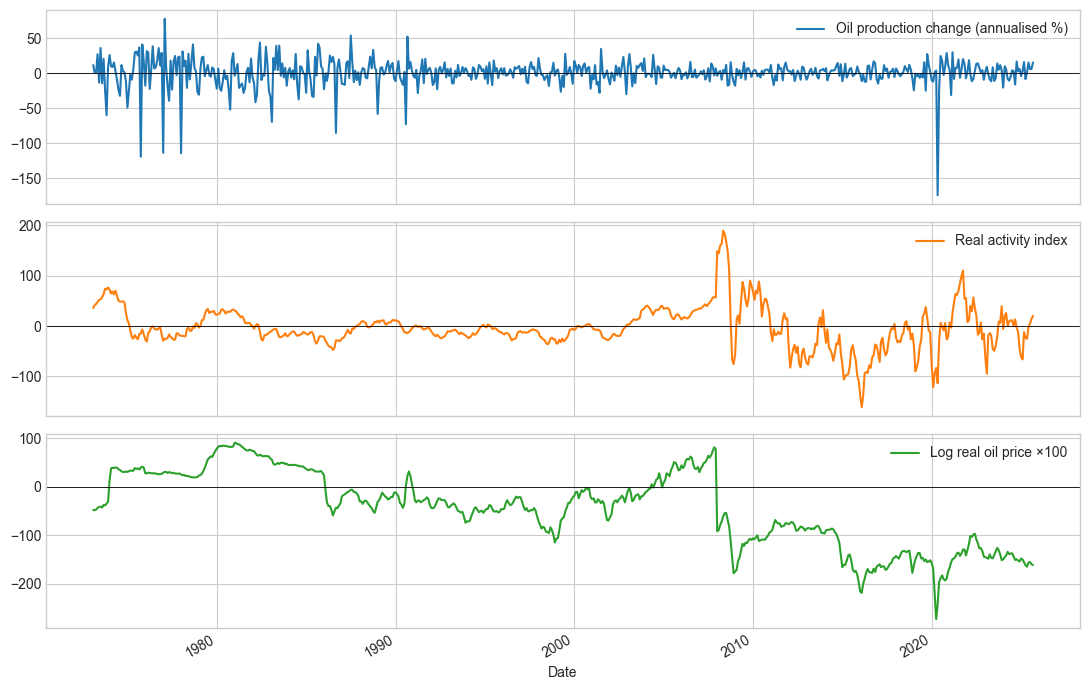

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(df.index, df['d_prod'], label='Oil production change (annualised %)')
axes[0].axhline(0, color='k', lw=0.6)
axes[0].legend()

axes[1].plot(df.index, df['rea'], label='Real activity index', color='tab:orange')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].legend()

axes[2].plot(df.index, df['rpo'], label='Log real oil price ×100', color='tab:green')
axes[2].axhline(0, color='k', lw=0.6)
axes[2].legend()

axes[2].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Stationarity checks (ADF and KPSS)

In [30]:
rows = []
for c in cols:
    s = df[c].dropna().values
    adf = adfuller(s, regression='c', autolag='AIC')
    kps = kpss(s, regression='c', nlags='auto')
    rows.append({
        'series': c,
        'adf_stat': adf[0],
        'adf_pvalue': adf[1],
        'kpss_stat': kps[0],
        'kpss_pvalue': kps[1]
    })
stationarity_table = pd.DataFrame(rows)
stationarity_table

/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_6049/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')
/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_6049/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')
/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_6049/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')


,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
0,d_prod,-6.026682,1.450329e-07,0.036947,0.10
1,rea,-4.417180,2.767273e-04,0.204174,0.10
2,rpo,-1.505072,5.310006e-01,2.619633,0.01


## AIC table by lag length

In [31]:
aic_rows = []
for lag in range(1, 37):
    try:
        res = VAR(df[cols]).fit(lag)
        aic_rows.append({'lag': lag, 'AIC': res.aic})
    except Exception:
        aic_rows.append({'lag': lag, 'AIC': np.nan})
aic_table = pd.DataFrame(aic_rows)
print("Lag with minimum AIC:", aic_table.loc[aic_table['AIC'].idxmin(), 'lag'])
aic_table

Lag with minimum AIC: 2


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

,lag,AIC
0,1,16.098686
1,2,15.947494
2,3,15.950050
3,4,15.964984
4,5,15.955090
5,6,15.975818
6,7,15.985813
7,8,16.000328
8,9,15.986551
9,10,15.968143


## BVAR(24) with NIW prior and Gibbs sampling

In [32]:
p = 24
n_draws = 12000
burn = 2000

# df[cols].values produces a pure float64 array — required for matrix arithmetic
bvar = gibbs_bvar_niw(df[cols].values.astype(float), p=p, n_draws=n_draws, burn=burn, seed=42)
bvar['B_mean'].shape, bvar['Sigma_mean']

((73, 3),
 array([[286.7751,   7.9039, -17.3809],
        [  7.9039, 180.5206, -16.0293],
        [-17.3809, -16.0293,  96.3122]]))

## MCMC trace plots (visual convergence check)

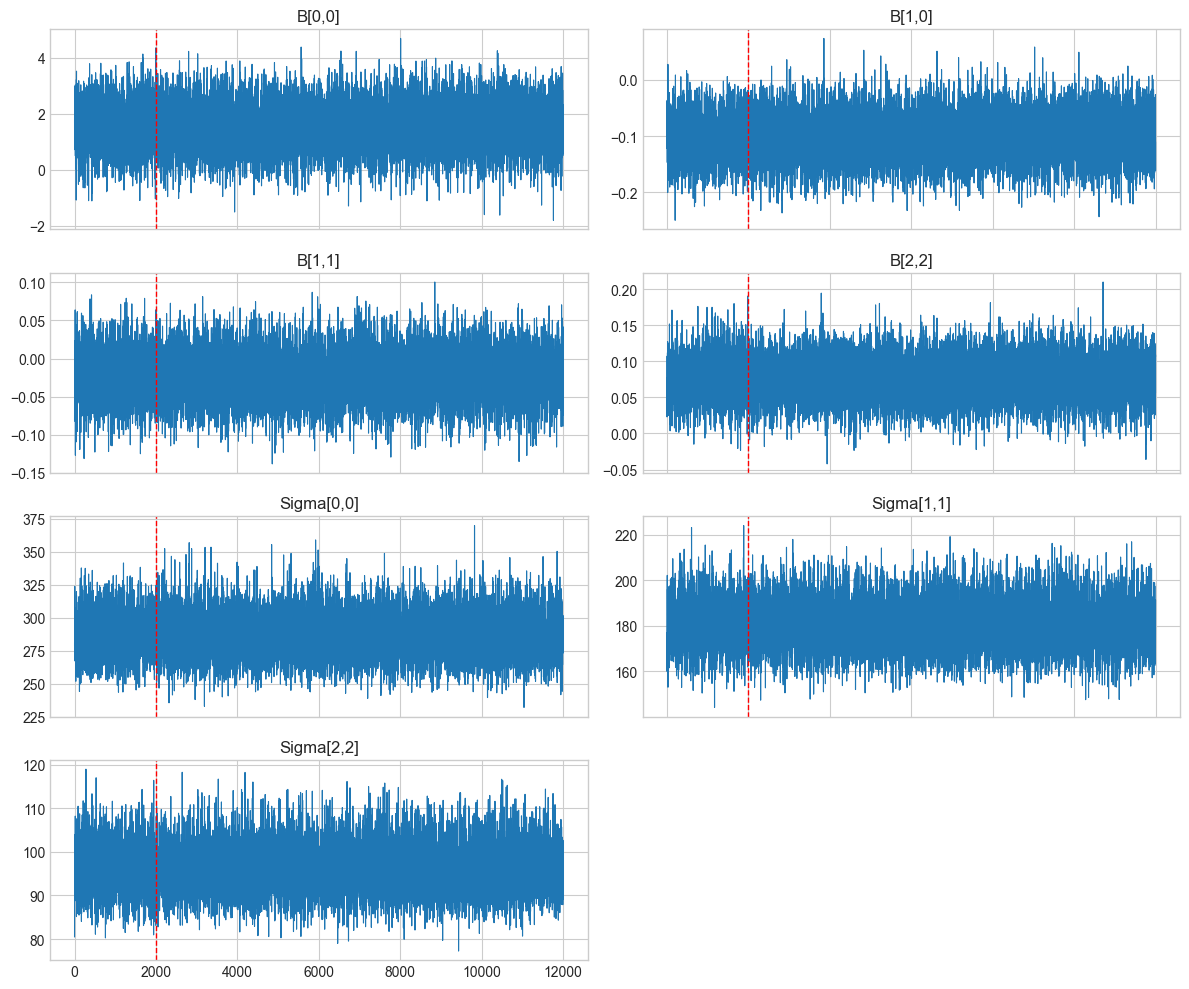

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

trace_names = ['B[0,0]', 'B[1,0]', 'B[1,1]', 'B[2,2]']
for i in range(4):
    axes[i].plot(bvar['B_trace'][:, i], lw=0.8)
    axes[i].axvline(2000, color='r', ls='--', lw=1)
    axes[i].set_title(trace_names[i])

sig_names = ['Sigma[0,0]', 'Sigma[1,1]', 'Sigma[2,2]']
for i in range(3):
    axes[4+i].plot(bvar['S_trace'][:, i], lw=0.8)
    axes[4+i].axvline(2000, color='r', ls='--', lw=1)
    axes[4+i].set_title(sig_names[i])

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Residual diagnostics (Ljung-Box test)

In [34]:
Y = bvar['Y']
X = bvar['X']
Bhat = bvar['B_mean']
resid = Y - X @ Bhat

lb_rows = []
for i, c in enumerate(cols):
    lb = acorr_ljungbox(resid[:, i], lags=[24], return_df=True)
    lb_rows.append({
        'series': c,
        'lb_stat_lag12': float(lb['lb_stat'].iloc[0]),
        'lb_pvalue_lag12': float(lb['lb_pvalue'].iloc[0])
    })
ljung_box_table = pd.DataFrame(lb_rows)
ljung_box_table

,series,lb_stat_lag12,lb_pvalue_lag12
0,d_prod,5.224554,0.999981
1,rea,18.706312,0.767465
2,rpo,3.390902,1.000000


## Running posterior mean over iterations

This plots the cumulative posterior mean (after burn-in) to visually inspect stabilization over MCMC draws.

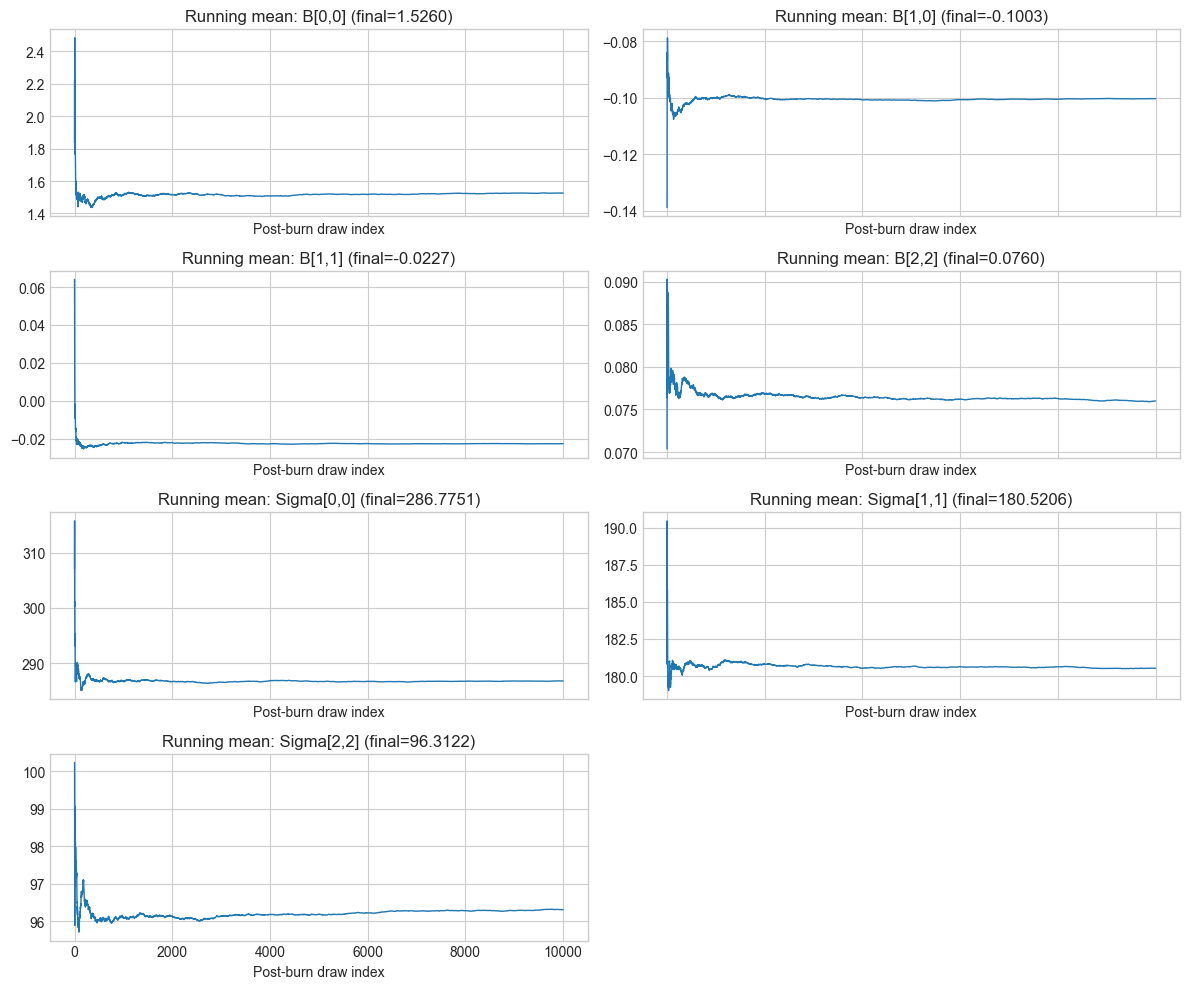

In [35]:
keep_B = bvar['B_draws']
keep_S = bvar['Sigma_draws']

cum_mean_B00 = np.cumsum(keep_B[:, 0, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B10 = np.cumsum(keep_B[:, 1, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B11 = np.cumsum(keep_B[:, 1, 1]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B22 = np.cumsum(keep_B[:, 2, 2]) / np.arange(1, keep_B.shape[0] + 1)

cum_mean_S00 = np.cumsum(keep_S[:, 0, 0]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S11 = np.cumsum(keep_S[:, 1, 1]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S22 = np.cumsum(keep_S[:, 2, 2]) / np.arange(1, keep_S.shape[0] + 1)

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

series = [
    (cum_mean_B00, 'Running mean: B[0,0]'),
    (cum_mean_B10, 'Running mean: B[1,0]'),
    (cum_mean_B11, 'Running mean: B[1,1]'),
    (cum_mean_B22, 'Running mean: B[2,2]'),
    (cum_mean_S00, 'Running mean: Sigma[0,0]'),
    (cum_mean_S11, 'Running mean: Sigma[1,1]'),
    (cum_mean_S22, 'Running mean: Sigma[2,2]'),
]

for i, (s, ttl) in enumerate(series):
    axes[i].plot(s, lw=1)
    axes[i].set_title(f"{ttl} (final={s[-1]:.4f})")
    axes[i].set_xlabel('Post-burn draw index')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Posterior estimates (intercept, lag-1, residuals)

Reduced-form BVAR equation $Y_t = X_t B + u_t$ with $u_t \sim \mathcal{N}(0,\Sigma)$.
The table reports posterior means and 95% credible intervals from post-burn-in Gibbs draws.
Structural shocks are identified later via Cholesky factorization of $\Sigma$ (Kilian ordering).

In [36]:
from posterior_table import posterior_bvar_summary, posterior_bvar_latex

n = bvar['B_draws'].shape[2]  # number of endogenous variables
post_summary = posterior_bvar_summary(
    bvar['B_draws'],
    bvar['Sigma_draws'],
    n=n,
)
display(post_summary.round(3))

notes = (
    f"Based on {bvar['B_draws'].shape[0]:,} post-burn-in draws "
    f"(burn-in = {burn:,}, total = {n_draws:,}). "
    "Endogenous order: oil production, real activity, real oil price. "
    r"$\Sigma_{ij}$ denotes the $(i,j)$ element of the reduced-form innovation covariance."
)
latex_table = posterior_bvar_latex(
    post_summary,
    caption="Posterior summaries of reduced-form BVAR(24) parameters (NIW prior, Gibbs sampler)",
    label="tab:posterior_bvar",
    notes=notes,
)
print(latex_table)

out_tex = BASE_DIR / 'script/output/posterior_table.tex'
out_tex.write_text(latex_table)
print(f"\nSaved: {out_tex}")

,block,equation,parameter,mean,sd,ci_lo,ci_hi
0,Intercept,Oil production,Constant,1.526,0.828,-0.107,3.168
1,Intercept,Real activity,Constant,0.472,0.665,-0.835,1.773
2,Intercept,Real oil price,Constant,-0.547,0.481,-1.477,0.410
3,Lag-1,Oil production,$\Delta prod_{t-1}$,-0.100,0.041,-0.180,-0.021
4,Lag-1,Oil production,$rea_{t-1}$,0.011,0.051,-0.089,0.110
5,Lag-1,Oil production,$rpo_{t-1}$,0.081,0.070,-0.057,0.218
6,Lag-1,Real activity,$\Delta prod_{t-1}$,-0.023,0.032,-0.085,0.040
7,Lag-1,Real activity,$rea_{t-1}$,1.076,0.040,0.998,1.152
8,Lag-1,Real activity,$rpo_{t-1}$,0.256,0.057,0.146,0.369
9,Lag-1,Real oil price,$\Delta prod_{t-1}$,-0.036,0.023,-0.081,0.010


% Auto-generated by posterior_table.posterior_bvar_latex
\begin{table}[htbp]
\centering
\caption{Posterior summaries of reduced-form BVAR(24) parameters (NIW prior, Gibbs sampler)}
\label{tab:posterior_bvar}
\small
\begin{tabular}{llcc}
\toprule
Equation & Regressor & Mean & 95\% credible interval \\
\midrule
\multicolumn{4}{l}{\textit{Intercept}} \\
Oil production & Constant & 1.526 & [-0.107, 3.168] \\
Real activity & Constant & 0.472 & [-0.835, 1.773] \\
Real oil price & Constant & -0.547 & [-1.477, 0.410] \\
\addlinespace
\multicolumn{4}{l}{\textit{Lag-1 coefficients}} \\
Oil production & $\Delta prod_{t-1}$ & -0.100 & [-0.180, -0.021] \\
Oil production & $rea_{t-1}$ & 0.011 & [-0.089, 0.110] \\
Oil production & $rpo_{t-1}$ & 0.081 & [-0.057, 0.218] \\
\addlinespace
Real activity & $\Delta prod_{t-1}$ & -0.023 & [-0.085, 0.040] \\
Real activity & $rea_{t-1}$ & 1.076 & [0.998, 1.152] \\
Real activity & $rpo_{t-1}$ & 0.256 & [0.146, 0.369] \\
\addlinespace
Real oil price & $\Delta pr

## Bayesian Figure 2: structural shocks (posterior mean parameters)

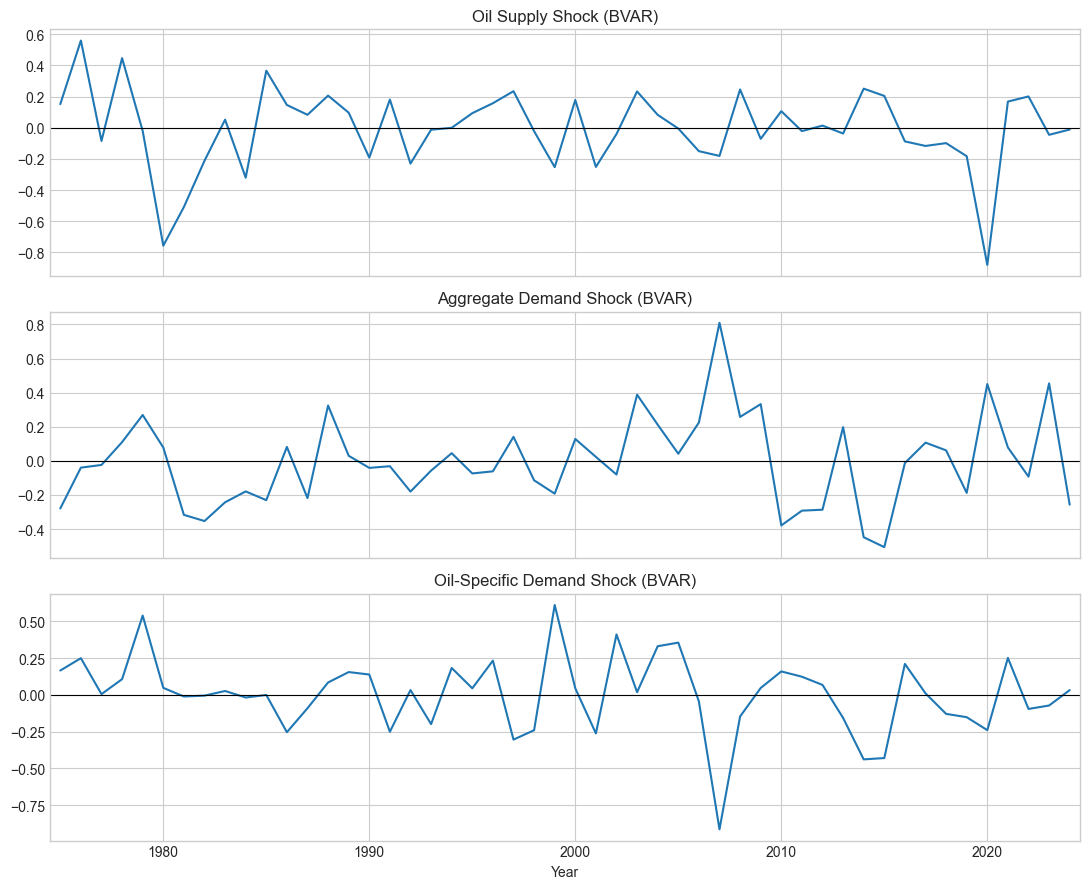

Showing annual averages for 50 complete years (1975–2024)


In [37]:
p = 24
n = 3
h = 15

# Use only numeric columns — df[cols].values is float64
y = df[cols].values.astype(float)
Ehat_b = structural_shocks_from_bmean(y, bvar['B_mean'], bvar['Sigma_mean'], p=p)

# Date axis: shocks start after p lags; df.index[p] is the first observation used
shock_dates = df.index[p:]

# Annual averages of monthly structural shocks
# We can only use complete 12-month blocks
n_shocks = Ehat_b.shape[1]  # number of shock observations available
n_full_years = n_shocks // 12
n_months_to_use = n_full_years * 12

year_min = shock_dates[0].year
time_year = np.arange(year_min, year_min + n_full_years)

def annual_avg(shock_row, n_months):
    """Average monthly shocks over complete years."""
    return shock_row[:n_months].reshape(-1, 12).mean(axis=1)

q1a = annual_avg(Ehat_b[0], n_months_to_use)
q2a = annual_avg(Ehat_b[1], n_months_to_use)
q3a = annual_avg(Ehat_b[2], n_months_to_use)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, s, ttl in zip(
    axes,
    [q1a, q2a, q3a],
    ['Oil Supply Shock (BVAR)', 'Aggregate Demand Shock (BVAR)', 'Oil-Specific Demand Shock (BVAR)']
):
    ax.plot(time_year, s) # use line plot instead
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlim(year_min - 0.5, time_year[-1] + 0.5)
    ax.set_title(ttl)

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

print(f"Showing annual averages for {n_full_years} complete years ({year_min}–{time_year[-1]})")

In [38]:
# Table: Cholesky-identified structural innovations (4-col: Equation, Regressor, Mean, 95% CI)
# eps_t = C^{-1} u_t,  u_t = y_t - X_t B,  C = chol(Sigma)' (Kilian ordering)
from structural_shock_table import (
    structural_innovations_posterior_table,
    structural_innovations_latex,
)

shock_table = structural_innovations_posterior_table(
    y, bvar['B_draws'], bvar['Sigma_draws'], p=p, max_draws=2000,
)
display(shock_table.round(4))

notes_shocks = (
    r"Sample covariance of $\hat\varepsilon_t$ at each Gibbs draw; "
    r"$\hat\varepsilon_t=\hat C^{-1}\hat u_t$ with $\hat C=\mathrm{chol}(\hat\Sigma)'$. "
    f"Ordering: oil production, real activity, real oil price. "
    "95% credible intervals from 2,000 thinned post-burn-in draws."
)
latex_shocks = structural_innovations_latex(
    shock_table,
    caption="Posterior summaries of structural innovations, BVAR(24)",
    label="tab:structural_innovations",
    section_title=r"\textit{Structural innovation covariance $\mathrm{Cov}(\varepsilon_t)$}",
    notes=notes_shocks,
)
print(latex_shocks)

out_shock_tex = BASE_DIR / 'script/output/structural_innovations_table.tex'
out_shock_tex.write_text(latex_shocks)
print(f"\nSaved: {out_shock_tex}")

,equation,parameter,mean,ci_lo,ci_hi
0,oil supply shock,$\Sigma_{11}$,1.1166,0.9992,1.2415
1,commodity agg. demand shock,$\Sigma_{21}$,-0.0038,-0.0731,0.0633
2,commodity agg. demand shock,$\Sigma_{22}$,1.1125,0.9932,1.2388
3,oil specific demand shock,$\Sigma_{33}$,1.1567,1.0425,1.2763
4,oil specific demand shock,$\Sigma_{31}$,-0.0489,-0.0994,0.0038
5,oil specific demand shock,$\Sigma_{32}$,-0.0388,-0.1024,0.0263


% Auto-generated by structural_shock_table.structural_innovations_latex
\begin{table}[htbp]
\centering
\caption{Posterior summaries of structural innovations, BVAR(24)}
\label{tab:structural_innovations}
\small
\begin{tabular}{llcc}
\toprule
Equation & Regressor & Mean & 95\% credible interval \\
\midrule
\multicolumn{4}{l}{\textit{Structural innovation covariance $\mathrm{Cov}(\varepsilon_t)$}} \\
oil supply shock & $\Sigma_{11}$ & 1.117 & [0.999, 1.241] \\
commodity agg. demand shock & $\Sigma_{21}$ & -0.004 & [-0.073, 0.063] \\
commodity agg. demand shock & $\Sigma_{22}$ & 1.112 & [0.993, 1.239] \\
oil specific demand shock & $\Sigma_{33}$ & 1.157 & [1.042, 1.276] \\
oil specific demand shock & $\Sigma_{31}$ & -0.049 & [-0.099, 0.004] \\
oil specific demand shock & $\Sigma_{32}$ & -0.039 & [-0.102, 0.026] \\
\bottomrule
\end{tabular}
\begin{minipage}{0.95\linewidth}
\footnotesize Sample covariance of $\hat\varepsilon_t$ at each Gibbs draw; $\hat\varepsilon_t=\hat C^{-1}\hat u_t$ wit

## Bayesian Figure 3: IRFs and credible intervals from posterior draws

# 4.1 FEVD

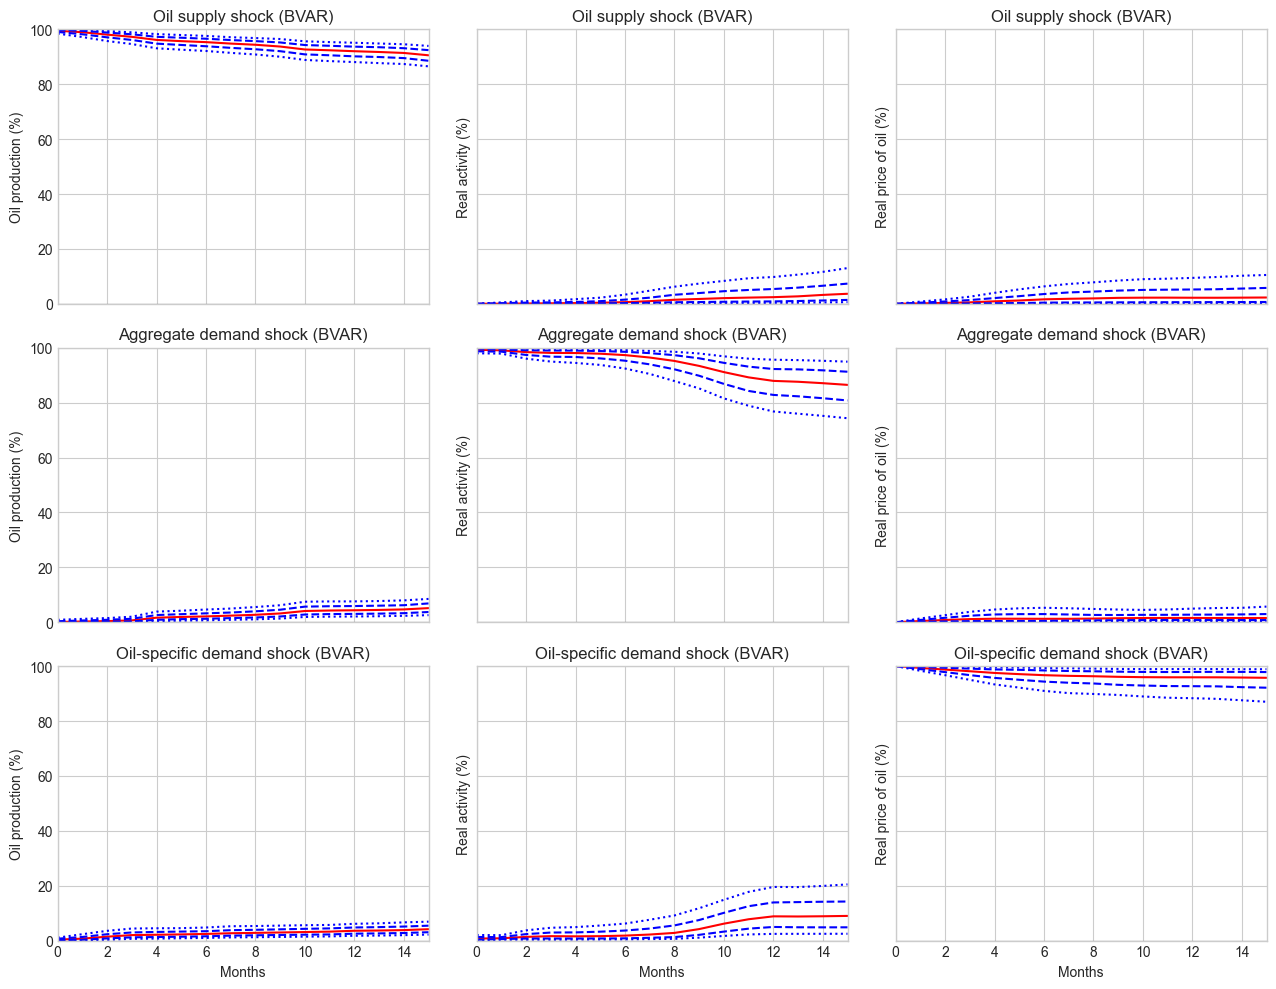

FEVD verification (should sum to ~100% for each variable at each horizon):
Oil production: h=0: 99.9%, h=6: 99.9%, h=15: 99.8%
Real activity: h=0: 100.0%, h=6: 99.7%, h=15: 99.1%
Real price of oil: h=0: 100.0%, h=6: 99.6%, h=15: 99.6%


In [40]:
# FEVD: posterior draws + credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

# FEVD_draws[d, shock, variable, horizon]
FEVD_draws = np.zeros((max_draws, n, n, h + 1))

for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)

    # irf_d uses order='F': [var1_shock1, var2_shock1, var3_shock1, var1_shock2, ...]
    # Reshape to (variable, shock, horizon) then transpose to (shock, variable, horizon)
    psi = irf_d.reshape(n, n, h + 1, order='F').transpose(1, 0, 2)

    # cumulative squared impulse responses up to horizon t
    cum_sq = np.cumsum(psi ** 2, axis=2)
    denom = np.sum(cum_sq, axis=0, keepdims=True)

    # avoid divide-by-zero at very early horizons
    FEVD_draws[j] = np.divide(cum_sq, denom, out=np.zeros_like(cum_sq), where=denom > 0)

FEVD_med = np.median(FEVD_draws, axis=0)
FEVD_68 = np.quantile(FEVD_draws, [0.16, 0.84], axis=0)
FEVD_95 = np.quantile(FEVD_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production'),
    ('Oil supply shock (BVAR)', 'Real activity'),
    ('Oil supply shock (BVAR)', 'Real price of oil'),
    ('Aggregate demand shock (BVAR)', 'Oil production'),
    ('Aggregate demand shock (BVAR)', 'Real activity'),
    ('Aggregate demand shock (BVAR)', 'Real price of oil'),
    ('Oil-specific demand shock (BVAR)', 'Oil production'),
    ('Oil-specific demand shock (BVAR)', 'Real activity'),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil'),
]

for k, (ttl, yl) in enumerate(meta):
    shock = k // n
    var = k % n

    med = 100.0 * FEVD_med[shock, var]
    l68 = 100.0 * FEVD_68[0, shock, var]
    u68 = 100.0 * FEVD_68[1, shock, var]
    l95 = 100.0 * FEVD_95[0, shock, var]
    u95 = 100.0 * FEVD_95[1, shock, var]

    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax = axes[k]
    ax.plot(horizon, med, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(f"{yl} (%)")
    ax.set_xlim(0, h)
    ax.set_ylim(0, 100)
    if k >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

# Verification: FEVD should sum to 100% across shocks for each variable
print("FEVD verification (should sum to ~100% for each variable at each horizon):")
for var in range(n):
    var_names = ['Oil production', 'Real activity', 'Real price of oil']
    fevd_sum = np.sum(FEVD_med[:, var, :], axis=0) * 100
    print(f"{var_names[var]}: h=0: {fevd_sum[0]:.1f}%, h=6: {fevd_sum[6]:.1f}%, h=15: {fevd_sum[15]:.1f}%")


In [41]:
# Granger causality tests (lag p=24, same as BVAR)
from IPython.display import display
from statsmodels.tsa.stattools import grangercausalitytests

var_names = ['d_prod', 'rea', 'rpo']
var_labels = {
    'd_prod': 'oil production (d_prod)',
    'rea': 'real activity (rea)',
    'rpo': 'real price of oil (rpo)',
}

# Bivariate tests: H0 = x does NOT Granger-cause y
# statsmodels: column 2 Granger-causes column 1 in [y, x]
bivariate_tests = [
    ('rea', 'd_prod', 'd_prod → rea'),
    ('rpo', 'd_prod', 'd_prod → rpo'),
    ('d_prod', 'rea', 'rea → d_prod'),
    ('rpo', 'rea', 'rea → rpo'),
    ('rea', 'rpo', 'rpo → rea'),
    ('d_prod', 'rpo', 'rpo → d_prod'),
]

bi_rows = []
for y_col, x_col, label in bivariate_tests:
    arr = df[[y_col, x_col]].values
    res = grangercausalitytests(arr, maxlag=[p], verbose=False)
    fstat, pval, df_denom, df_num = res[p][0]['ssr_ftest']
    bi_rows.append({
        'direction': label,
        'cause': var_labels[x_col],
        'effect': var_labels[y_col],
        'F_stat': fstat,
        'p_value': pval,
        'reject_5pct': pval < 0.05,
    })

bivariate_gc = pd.DataFrame(bi_rows)
print('Bivariate Granger causality (H0: no causality):')
display(bivariate_gc.style.format({'F_stat': '{:.3f}', 'p_value': '{:.4f}'}))

# Multivariate tests: H0 = lags of "cause" do not help predict all other variables
var_ols = VAR(df[var_names]).fit(p)
mv_rows = []
for cause in var_names:
    caused = [c for c in var_names if c != cause]
    tc = var_ols.test_causality(caused=caused, causing=cause)
    mv_rows.append({
        'cause': var_labels[cause],
        'effect': 'all other variables',
        'F_stat': tc.test_statistic,
        'p_value': tc.pvalue,
        'reject_5pct': tc.pvalue < 0.05,
    })

multivariate_gc = pd.DataFrame(mv_rows)
print('\nMultivariate Granger causality (conditional on full VAR):')
display(multivariate_gc.style.format({'F_stat': '{:.3f}', 'p_value': '{:.4f}'}))

# Pairwise FEVD at h=15 for comparison (median across posterior draws if FEVD_med exists)
if 'FEVD_med' in globals():
    h_fevd = FEVD_med.shape[2] - 1
    fevd_h = 100 * FEVD_med[:, :, h_fevd]
    fevd_diag = pd.Series(
        {var_labels[var_names[i]]: fevd_h[i, i] for i in range(n)},
        name=f'own-shock FEVD at h={h_fevd} (%)',
    )
    print(f'\nDiagonal FEVD shares at horizon h={h_fevd} (posterior median):')
    display(fevd_diag.to_frame())


Bivariate Granger causality (H0: no causality):


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

,direction,cause,effect,F_stat,p_value,reject_5pct
0,d_prod → rea,oil production (d_prod),real activity (rea),0.628,0.9161,False
1,d_prod → rpo,oil production (d_prod),real price of oil (rpo),0.331,0.9990,False
2,rea → d_prod,real activity (rea),oil production (d_prod),1.115,0.3213,False
3,rea → rpo,real activity (rea),real price of oil (rpo),0.812,0.7236,False
4,rpo → rea,real price of oil (rpo),real activity (rea),3.333,0.0000,True
5,rpo → d_prod,real price of oil (rpo),oil production (d_prod),0.899,0.6038,False



Multivariate Granger causality (conditional on full VAR):


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,cause,effect,F_stat,p_value,reject_5pct
0,oil production (d_prod),all other variables,0.476,0.9992,False
1,real activity (rea),all other variables,0.875,0.7133,False
2,real price of oil (rpo),all other variables,1.996,0.0001,True



Diagonal FEVD shares at horizon h=15 (posterior median):


,own-shock FEVD at h=15 (%)
oil production (d_prod),90.539485
real activity (rea),86.461809
real price of oil (rpo),95.741240


In [42]:
# LaTeX tables for Granger causality summary (requires \usepackage{booktabs})
def _sig_stars(p):
    if p < 0.01:
        return r'$^{***}$'
    if p < 0.05:
        return r'$^{**}$'
    if p < 0.10:
        return r'$^{*}$'
    return ''


def granger_table_latex(df, columns, col_names, caption, label, col_format):
    out = df[columns].copy()
    out.columns = col_names
    if 'p_value' in columns:
        p_name = col_names[columns.index('p_value')]
        out[p_name] = [f'{p:.4f}{_sig_stars(p)}' for p in df['p_value']]
    if 'F_stat' in columns:
        f_name = col_names[columns.index('F_stat')]
        out[f_name] = [f'{x:.3f}' for x in df['F_stat']]
    return out.to_latex(
        index=False,
        column_format=col_format,
        caption=caption,
        label=label,
        escape=False,
    )


bi_latex = granger_table_latex(
    bivariate_gc,
    columns=['direction', 'F_stat', 'p_value'],
    col_names=['Direction', r'$F$', r'$p$-value'],
    caption=(
        f'Bivariate Granger causality tests at lag $p={p}$. '
        r'H$_0$: the cause variable does not Granger-cause the effect variable.'
    ),
    label='tab:granger_bivariate',
    col_format='lrr',
)

mv_latex = granger_table_latex(
    multivariate_gc,
    columns=['cause', 'F_stat', 'p_value'],
    col_names=['Cause (lags enter)', r'$F$', r'$p$-value'],
    caption=(
        f'Multivariate Granger causality tests at lag $p={p}$ (VAR system). '
        r'H$_0$: lags of the cause do not help predict all other endogenous variables.'
    ),
    label='tab:granger_multivariate',
    col_format='lrr',
)

print('% Preamble: \\usepackage{booktabs}')
print()
print('% --- Bivariate Granger causality ---')
print(bi_latex)
print()
print('% --- Multivariate Granger causality ---')
print(mv_latex)

if 'FEVD_med' in globals():
    h_fevd = FEVD_med.shape[2] - 1
    fevd_h = 100 * FEVD_med[:, :, h_fevd]
    fevd_diag_df = pd.DataFrame({
        'Variable': [var_labels[v] for v in var_names],
        f'Own-shock FEVD at $h={h_fevd}$ (\\%)': [fevd_h[i, i] for i in range(n)],
    })
    fevd_latex = fevd_diag_df.to_latex(
        index=False,
        column_format='lr',
        caption=(
            f'Diagonal forecast error variance shares at horizon $h={h_fevd}$ '
            '(posterior median, percent).'
        ),
        label='tab:fevd_diagonal',
        float_format='%.1f',
    )
    print()
    print('% --- Diagonal FEVD (comparison) ---')
    print(fevd_latex)


% Preamble: \usepackage{booktabs}

% --- Bivariate Granger causality ---
\begin{table}
\caption{Bivariate Granger causality tests at lag $p=24$. H$_0$: the cause variable does not Granger-cause the effect variable.}
\label{tab:granger_bivariate}
\begin{tabular}{lrr}
\toprule
Direction & $F$ & $p$-value \\
\midrule
d_prod → rea & 0.628 & 0.9161 \\
d_prod → rpo & 0.331 & 0.9990 \\
rea → d_prod & 1.115 & 0.3213 \\
rea → rpo & 0.812 & 0.7236 \\
rpo → rea & 3.333 & 0.0000$^{***}$ \\
rpo → d_prod & 0.899 & 0.6038 \\
\bottomrule
\end{tabular}
\end{table}


% --- Multivariate Granger causality ---
\begin{table}
\caption{Multivariate Granger causality tests at lag $p=24$ (VAR system). H$_0$: lags of the cause do not help predict all other endogenous variables.}
\label{tab:granger_multivariate}
\begin{tabular}{lrr}
\toprule
Cause (lags enter) & $F$ & $p$-value \\
\midrule
oil production (d_prod) & 0.476 & 0.9992 \\
real activity (rea) & 0.875 & 0.7133 \\
real price of oil (rpo) & 1.996 & 0.0001$

## Bayesian Figure 4: cumulative effect on real oil price

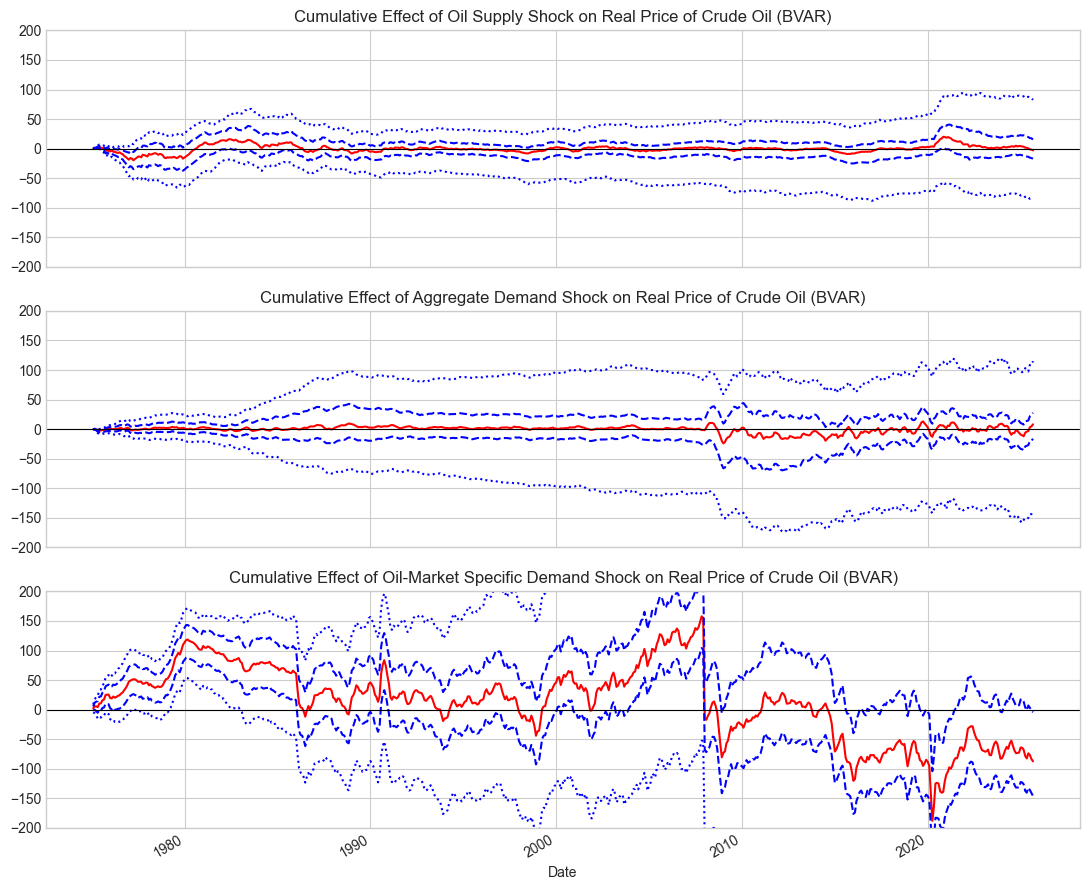

In [43]:
oil_ci = posterior_draw_CI(y, bvar['B_draws'], bvar['Sigma_draws'], p=p, n=n)

# Date axis aligned to the actual data: first shock date is df.index[p]
time_dates = df.index[p:]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

titles = [
    'Cumulative Effect of Oil Supply Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Aggregate Demand Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Oil-Market Specific Demand Shock on Real Price of Crude Oil (BVAR)',
]
for shock, ax in enumerate(axes):
    m = oil_ci['median'][shock]
    l68, u68 = oil_ci['q68'][0, shock], oil_ci['q68'][1, shock]
    l95, u95 = oil_ci['q95'][0, shock], oil_ci['q95'][1, shock]
    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax.plot(time_dates, m, 'r-')
    ax.plot(time_dates, lo68, 'b--')
    ax.plot(time_dates, hi68, 'b--')
    ax.plot(time_dates, lo95, 'b:')
    ax.plot(time_dates, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(titles[shock])
    ax.set_ylim(-200, 200)

axes[-1].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Bayesian Figure 5-style responses: shocks on real GDP and CPI

In [44]:
# Load merged GDP and CPI data (Kilian's original 1974-2007 + extension 2008-2025)
# These files were created by fetching GDPC1 and CPIAUCSL from FRED

# GDP: quarterly real GDP in billions of chained dollars
beagdp_merged = np.loadtxt(BASE_DIR / 'data/beagdp_merged_1974_2025.txt')
print("GDP data loaded:")
print(f"  Range: {int(beagdp_merged[0,0])} Q{int(beagdp_merged[0,1])} → "
      f"{int(beagdp_merged[-1,0])} Q{int(beagdp_merged[-1,1])}")
print(f"  Quarters: {len(beagdp_merged)}")

# CPI: monthly CPI-U (all urban consumers)
cpi_merged = np.loadtxt(BASE_DIR / 'data/cpi_merged_1974_2025.txt')
print("\nCPI data loaded:")
print(f"  Range: {int(cpi_merged[0,0])}-{int(cpi_merged[0,1]):02d} → "
      f"{int(cpi_merged[-1,0])}-{int(cpi_merged[-1,1]):02d}")
print(f"  Months: {len(cpi_merged)}") 


GDP data loaded:
  Range: 1974 Q4 → 2025 Q4
  Quarters: 205

CPI data loaded:
  Range: 1974-12 → 2025-12
  Months: 612



Stage-2 alignment:
  Quarterly shocks : 203 quarters (q1q, q2q, q3q)
  GDP growth       : 203 quarters
  CPI inflation    : 202 quarters
  First quarter    : 1975 Q1
  Used for GDP stage-2: 203 quarters
  Used for CPI stage-2: 202 quarters


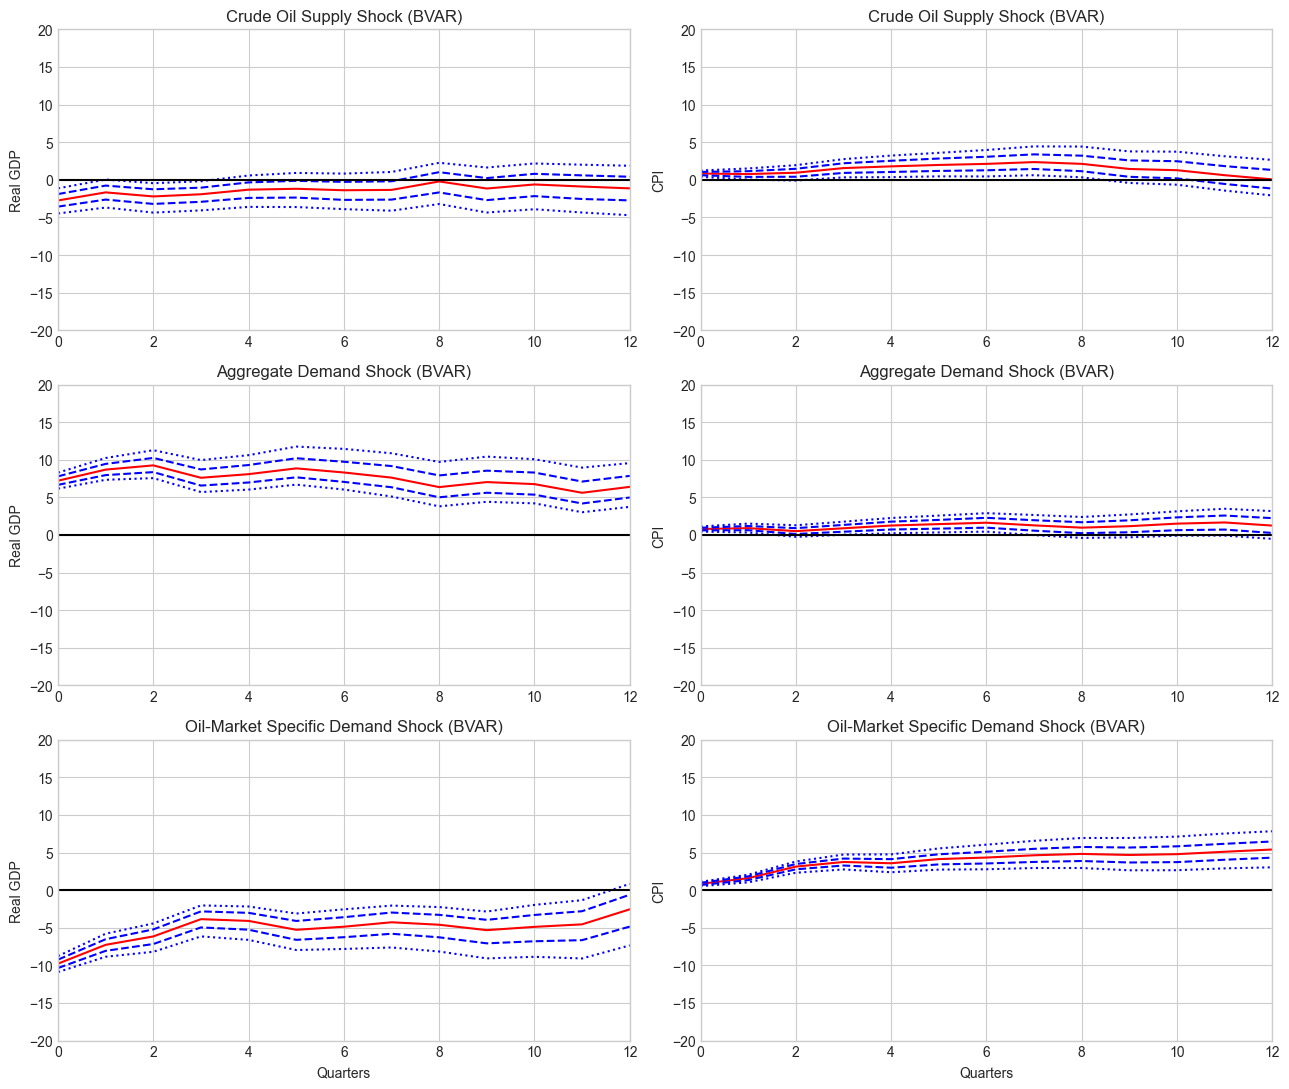

In [45]:
# ═════════════════════════════════════════════════════════════════════════════
# Stage-2 setup: quarterly oil shocks → GDP growth and CPI inflation
# ═════════════════════════════════════════════════════════════════════════════

# Quarterly average structural shocks from monthly BVAR estimates
shock_dates = df.index[p:]  # first shock: 2010-01 (after p=24 lags from 2008-01)

# Pad with initial value (Kilian convention: average first two months)
q1 = np.concatenate([[(Ehat_b[0, 0] + Ehat_b[0, 1]) / 2], Ehat_b[0, :]])
q2 = np.concatenate([[(Ehat_b[1, 0] + Ehat_b[1, 1]) / 2], Ehat_b[1, :]])
q3 = np.concatenate([[(Ehat_b[2, 0] + Ehat_b[2, 1]) / 2], Ehat_b[2, :]])

# Quarterly averages (drop incomplete trailing months)
nq = len(q1) // 3
q1q = q1[:3 * nq].reshape(-1, 3).mean(axis=1)
q2q = q2[:3 * nq].reshape(-1, 3).mean(axis=1)
q3q = q3[:3 * nq].reshape(-1, 3).mean(axis=1)

# ─────────────────────────────────────────────────────────────────────────────
# GDP growth rate (quarterly, annualized %)
# ─────────────────────────────────────────────────────────────────────────────
gdp_vals = beagdp_merged[:, 2]  # column 3: real GDP
y_gdp_full = (np.log(gdp_vals[1:]) - np.log(gdp_vals[:-1])) * 400

# Align with quarterly shocks: first shock quarter is 2010 Q1
first_shock_year = shock_dates[0].year
first_shock_qtr = (shock_dates[0].month - 1) // 3 + 1

gdp_start_year = int(beagdp_merged[0, 0])
gdp_start_qtr = int(beagdp_merged[0, 1])

# Quarters from GDP start to first shock
offset_q = (first_shock_year - gdp_start_year) * 4 + (first_shock_qtr - gdp_start_qtr)

# Extract aligned GDP growth (same length as quarterly shocks)
y_gdp = y_gdp_full[offset_q - 1 : offset_q - 1 + nq, None]

# ─────────────────────────────────────────────────────────────────────────────
# CPI inflation rate (quarterly, annualized %)
# ─────────────────────────────────────────────────────────────────────────────
cpi_vals = cpi_merged[:, 2]
cpi_log = np.log(cpi_vals)

# Quarterly inflation: (log(CPI_end) - log(CPI_start)) × 400 for each quarter
first_cpi_idx = offset_q * 3  # months from CPI start to first shock quarter

infl_q = []
for i in range(nq):
    idx_start = first_cpi_idx + i * 3
    idx_end = idx_start + 3
    if idx_end < len(cpi_log) and not np.isnan(cpi_vals[idx_end]):
        infl_q.append((cpi_log[idx_end] - cpi_log[idx_start]) * 400)
    else:
        # Hit NaN or end of data — stop here
        break

y_cpi = np.array(infl_q)[:, None]

print(f"\nStage-2 alignment:")
print(f"  Quarterly shocks : {nq} quarters (q1q, q2q, q3q)")
print(f"  GDP growth       : {y_gdp.shape[0]} quarters")
print(f"  CPI inflation    : {y_cpi.shape[0]} quarters")
print(f"  First quarter    : {first_shock_year} Q{first_shock_qtr}")

# Align lengths explicitly for stage-2 regressions
nq_gdp = min(len(q1q), y_gdp.shape[0])
nq_cpi = min(len(q1q), y_cpi.shape[0])

y_gdp_use = y_gdp[:nq_gdp]
y_cpi_use = y_cpi[:nq_cpi]

print(f"  Used for GDP stage-2: {nq_gdp} quarters")
print(f"  Used for CPI stage-2: {nq_cpi} quarters")

# Stage-2 responses: posterior credible bands (reuses Ehat_draws from oil_ci)
if 'oil_ci' not in globals():
    oil_ci = posterior_draw_CI(y, bvar['B_draws'], bvar['Sigma_draws'], p=p, n=n)

Ehat_draws = oil_ci['Ehat_draws']
r2 = stage2_posterior_ci(y_gdp_use, Ehat_draws, shock_idx=0, nq=nq_gdp)
r3 = stage2_posterior_ci(y_gdp_use, Ehat_draws, shock_idx=1, nq=nq_gdp)
r4 = stage2_posterior_ci(y_gdp_use, Ehat_draws, shock_idx=2, nq=nq_gdp)

c2 = stage2_posterior_ci(y_cpi_use, Ehat_draws, shock_idx=0, nq=nq_cpi)
c3 = stage2_posterior_ci(y_cpi_use, Ehat_draws, shock_idx=1, nq=nq_cpi)
c4 = stage2_posterior_ci(y_cpi_use, Ehat_draws, shock_idx=2, nq=nq_cpi)

h2 = np.arange(13)
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

# GDP panels
for ax, rr, ttl, sgn in [
    (axes[0, 0], r2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 0], r3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 0], r4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('Real GDP')
    ax.set_title(ttl)
axes[2, 0].set_xlabel('Quarters')

# CPI panels
for ax, rr, ttl, sgn in [
    (axes[0, 1], c2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 1], c3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 1], c4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('CPI')
    ax.set_title(ttl)
axes[2, 1].set_xlabel('Quarters')

plt.tight_layout()
plt.show()